# Black Signal

В каждой спектрограмме закодирована последовательность из пяти цифр. Этот baseline читает PNG как одноканальное изображение, обучает небольшую CNN и формирует `submission.csv`.

При запуске ноутбук создаёт два файла:

- `fresh_checkpoint.pt` — веса после одной эпохи обучения в текущем запуске;
- `submission.csv` — предсказания для тестовой выборки.

Для инференса используется `datasets/solution/model.pt` — ваш заранее полностью обученный checkpoint, добавленный в workspace как отдельный набор данных.

In [192]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.9 MB/s  0:00:01 eta 0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.5 MB/s  0:00:00
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/Users/artyomkonukhov/Library/Python/3.14/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [196]:
from pathlib import Path
import random
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
import copy

SEED = 42
BATCH_SIZE = 32
TARGET_WIDTH = 384

DATA_DIR = Path("datasets")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

FRESH_CHECKPOINT_PATH = Path("fresh_checkpoint.pt")
FULL_CHECKPOINT_PATH = DATA_DIR / "solution" / "model.pt"
SUBMISSION_PATH = Path("submission.csv")

random.seed(SEED)
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

Matplotlib is building the font cache; this may take a moment.


## Данные

Спектрограмма переводится в grayscale, разворачивается по частотной оси, нормализуется в диапазон `[0, 1]` и дополняется нулями или обрезается до ширины `384`. Колонка с именем PNG может называться `id` или `file`.

In [76]:
def image_path(directory: Path, image_id: str) -> Path:
    path = directory / str(image_id)
    if path.suffix.lower() != ".png":
        path = path.with_suffix(".png")
    return path


def load_spectrogram(path: Path) -> torch.Tensor:
    # print(path)
    image = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    image = image[::-1] / 255.0

    padding = max(0, TARGET_WIDTH - image.shape[1])
    image = np.pad(image, ((0, 0), (0, padding)))[:, :TARGET_WIDTH]
    image = np.ascontiguousarray(image)

    return torch.from_numpy(image).unsqueeze(0)


class SpectrogramDataset(Dataset):
    def __init__(self, table: pd.DataFrame, directory: Path):
        self.table = table.reset_index(drop=True)
        self.directory = directory
        self.image_column = "file" if "file" in table.columns else "id"

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, index: int):
        row = self.table.iloc[index]
        image = load_spectrogram(image_path(self.directory, row[self.image_column]))
        target = torch.tensor([int(digit) for digit in row["code"]], dtype=torch.long)
        return image, target


train_df = pd.read_csv(TRAIN_DIR / "labels.csv", dtype=str)
test_df = pd.read_csv(TEST_DIR / "labels.csv", dtype=str)
train_df["code"] = train_df["code"].str.zfill(5)

train_dataset = SpectrogramDataset(train_df, TRAIN_DIR)
n = int(len(train_dataset) * 0.8)
train_subset = Subset(train_dataset, range(n))
val_subset = Subset(train_dataset, range(n, len(train_dataset)))
test_dataset = SpectrogramDataset(test_df, TEST_DIR)
tr_dl = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
va_dl = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
t_dl = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_df)} samples")
print(f"Test:  {len(test_df)} samples")

Train: 360 samples
Test:  3 samples


In [243]:
test_df

,file,level
0,public_0000.png,1
1,public_0001.png,2
2,public_0002.png,3


In [92]:
train_df.head()

,file,level,code
0,train_0000.png,1,74701
1,train_0001.png,2,66909
2,train_0002.png,3,35348
3,train_0003.png,4,89623
4,train_0004.png,5,28951


In [177]:
train_df.level.value_counts()

level
1    72
2    72
3    72
4    72
5    72
Name: count, dtype: int64

In [184]:
train_df.level = train_df.level.astype(int)

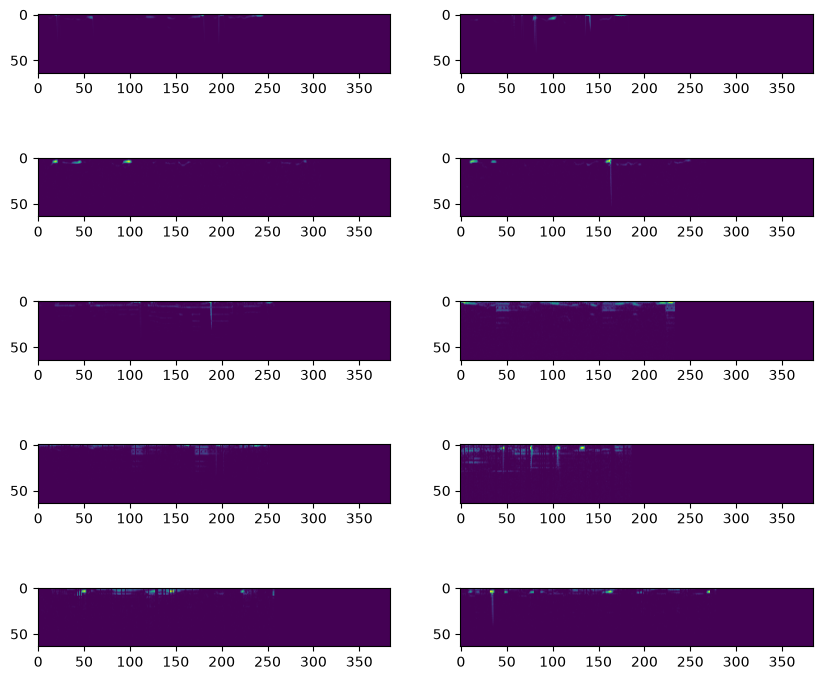

In [238]:
n_cols = 2
fig, ax = plt.subplots(5, n_cols, figsize=(10, 9))
for cls in range(1, 6):
    for i, row in enumerate(train_df[train_df.level == cls].file.sample(n_cols)):
        ax[cls-1, i].imshow(load_spectrogram(TRAIN_DIR / row).squeeze(0))

plt.show()
        
    

In [130]:
X = torch.tensor(train_df.file.apply(lambda file: load_spectrogram(TRAIN_DIR / file).numpy()).to_list())
X.shape

torch.Size([360, 1, 64, 384])

In [102]:
y = torch.tensor(train_df.code.apply(lambda code: [int(digit) for digit in code]).to_list())

## Модель и одна эпоха обучения

Модель выдаёт тензор размера `5 × 10`: для каждой из пяти позиций — логиты десяти цифр. Свежий checkpoint сохраняется сразу после одной эпохи.

In [126]:
def build_model() -> nn.Module:
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(4),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((4, 8)),
        nn.Flatten(),
        nn.Linear(32 * 4 * 8, 5 * 10),
        nn.Unflatten(1, (5, 10)),
    )


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    crit
) -> float:
    model.train()
    tl = 0.0
    total = 0
    
    for images, targets in loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = crit(logits.reshape(-1, 10), targets.reshape(-1))
        # print(logits.argmax(2).shape)
        # print(targets.shape)
        total += (logits.argmax(2) == targets).sum().item()

        loss.backward()
        optimizer.step()
        tl += loss.item() * len(images)

    return total / len(loader.dataset), tl / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, opt, crit):
    model.eval()
    tl = 0.0; total = 0
    for xb, vb in loader:
        probs = model(xb)
        loss = crit(probs.reshape(-1, 10), vb.reshape(-1))
        total += (probs.argmax(2) == vb).sum().item()
        tl += loss * len(xb)
    return total / len(loader.dataset), tl / len(loader.dataset)
    
NUM_EPOCHS = 10
fresh_model = build_model()
crit = nn.CrossEntropyLoss()

PATIENCE = 3
LEARNING_RATE = 1e-3
opt = torch.optim.Adam(fresh_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

best_acc = 0
bad_ep = 0
for i in range(NUM_EPOCHS):
    tr_acc, tr_l = train_one_epoch(fresh_model, tr_dl, opt, crit)
    va_acc, va_l = evaluate(fresh_model, va_dl, opt, crit)
    print(f"ep={i}, tr_acc={tr_acc:.4f}, va_acc={va_acc:.4f}")
    if va_acc > best_acc:
        best_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())
    else:
        bad_ep += 1
        if bad_ep >= PATIENCE:
            break
model.load_state_dict(best_state)
print(f"best_acc={best_acc}")

ep=0, tr_acc=0.5069, va_acc=0.5139
ep=1, tr_acc=0.6285, va_acc=0.5000
ep=2, tr_acc=0.6354, va_acc=0.4722
ep=3, tr_acc=0.6354, va_acc=0.4444
best_acc=0.5138888888888888


In [149]:
def overfit_one(model, opt, tr_b, v_b, steps=301):
    for i in range(steps):
        logits = model(tr_b)
        loss = crit(logits.reshape(-1, 10), v_b.reshape(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()
        acc = (logits.argmax(2) == v_b).sum().item() / (len(v_b) * 5)
        if i % 25 == 0: print(f"step={i}, acc={acc}")
    return acc

In [171]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, stride=2, bias=False), #64, 384
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2, bias=False), #32, 192
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False), #16, 96
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.AdaptiveAvgPool2d((1, 5))
        )
        self.classifier = nn.Linear(64, 10)

    def forward(self, x):
        out = self.features(x) # B, 64, 1, 5
        out = out.squeeze(2) # B, 64, 5
        out = out.transpose(1, 2) # B, 5, 64
        return self.classifier(out) # B, 5, 10

In [175]:
model = DigitCNN()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
overfit_one(model, opt, X[:32], y[:32], steps=5001)

step=0, acc=0.0875
step=25, acc=0.2875
step=50, acc=0.45
step=75, acc=0.55625
step=100, acc=0.7
step=125, acc=0.725
step=150, acc=0.74375
step=175, acc=0.75
step=200, acc=0.75
step=225, acc=0.775
step=250, acc=0.775
step=275, acc=0.775
step=300, acc=0.775
step=325, acc=0.7625
step=350, acc=0.775
step=375, acc=0.775
step=400, acc=0.775


KeyboardInterrupt: 

In [164]:
sum([p.numel() for p in model.parameters()])

24058

## Инференс и submission

Для итогового предсказания загружаются полностью обученные веса из `datasets/solution/model.pt`. Функция `predict` принимает путь к одному PNG и возвращает строку из пяти цифр.

In [10]:
model = build_model()
model.load_state_dict(torch.load(FULL_CHECKPOINT_PATH, map_location="cpu"))
model.eval()


@torch.inference_mode()
def predict(png_path: str | Path) -> str:
    image = load_spectrogram(Path(png_path)).unsqueeze(0)
    digits = model(image).argmax(dim=-1).squeeze(0).tolist()
    return "".join(map(str, digits))


test_image_column = "file" if "file" in test_df.columns else "id"
submission_ids = test_df["id"] if "id" in test_df.columns else test_df[test_image_column]

submission = pd.DataFrame(
    {
        "id": submission_ids,
        "code": [
            predict(image_path(TEST_DIR, image_id))
            for image_id in test_df[test_image_column]
        ],
    }
)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved: {SUBMISSION_PATH}")
submission.head()

Saved: submission.csv


,id,code
0,public_0000.png,42703
1,public_0001.png,42703
2,public_0002.png,42303
